In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

In [7]:
#Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

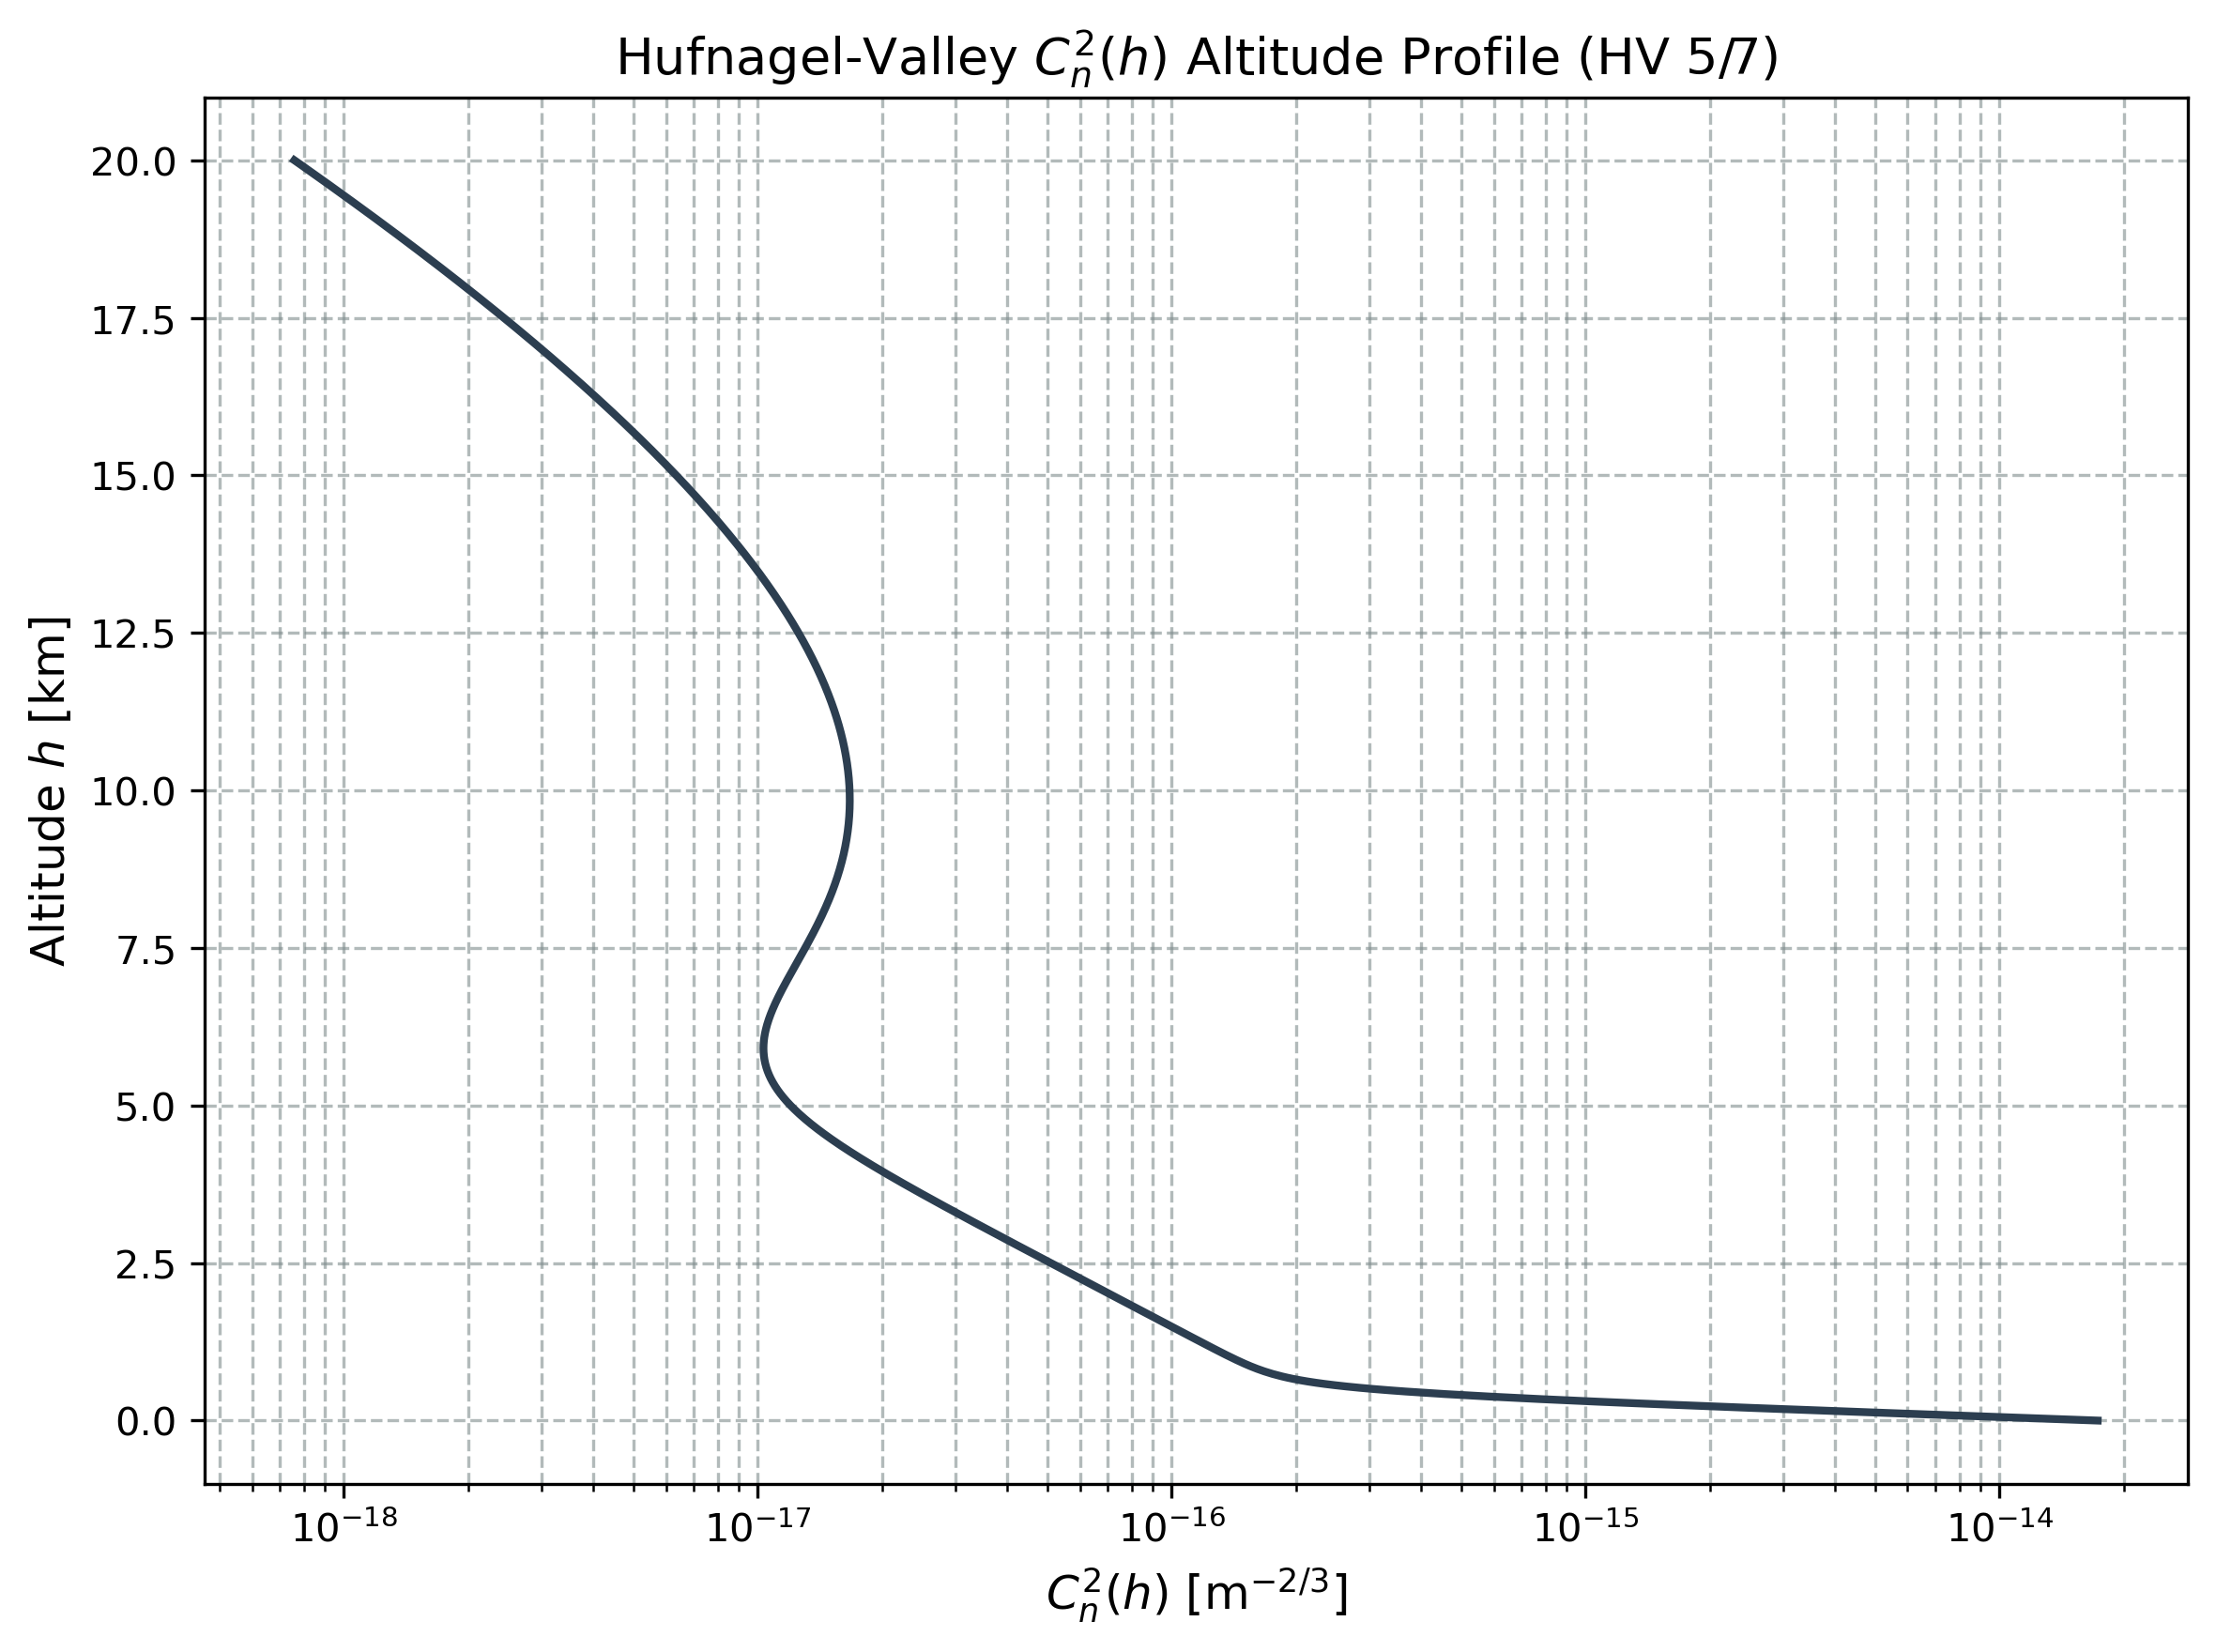

Calculated r0 at 1064 nm (zenith): 12.28 cm


In [8]:



def hufnagel_valley_cn2(h, A=1.7e-14, w=21):
  """Calculates the Hufnagel-Valley Cn^2(h) altitude profile.

  Parameters:
  h : float or np.ndarray
      Altitude in meters [m]
  A : float
      Ground-level turbulence amplitude [m^(-2/3)] (default for HV 5/7)
  w : float
      RMS pseudo-wind speed in [m/s] (default for HV 5/7 is 21 m/s)
  """
  term1 = 0.00594 * (w / 27) ** 2 * (h * 1e-5) ** 10 * np.exp(-h / 1000.0)
  term2 = 2.7e-16 * np.exp(-h / 1500.0)
  term3 = A * np.exp(-h / 100.0)
  return term1 + term2 + term3


# Altitude profile from 0 to 20 km
h_altitudes = np.linspace(0, 20000, 1000)
cn2_profile = hufnagel_valley_cn2(h_altitudes)

# ==========================================
# Plotting the Refractive Index Structure Constant
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(cn2_profile, h_altitudes / 1e3, color="#2C3E50", lw=2)
ax.set_xscale("log")
ax.set_xlabel(r"$C_n^2(h)$ [$\text{m}^{-2/3}$]")
ax.set_ylabel("Altitude $h$ [km]")
ax.set_title("Hufnagel-Valley $C_n^2(h)$ Altitude Profile (HV 5/7)")
ax.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# ==========================================
# Optional: Calculating Fried Parameter r0 for a given wavelength
# ==========================================
def calculate_fried_parameter(
    lam, h_max=20000, A=1.7e-14, w=21, zenith_angle_deg=0
):
  k = 2 * np.pi / lam
  sec_theta = 1.0 / np.cos(np.radians(zenith_angle_deg))

  # Integrate Cn^2(h) from 0 to h_max
  integral, _ = quad(lambda h: hufnagel_valley_cn2(h, A, w), 0, h_max)

  # r0 = [0.423 * k^2 * sec(theta) * integral(Cn^2) dh]^(-3/5)
  r0 = (0.423 * k**2 * sec_theta * integral) ** (-3.0 / 5.0)
  return r0


# Test calculation for 1064 nm at zenith
wavelength = 1064e-9  # [m]
r0_1064 = calculate_fried_parameter(wavelength, zenith_angle_deg=0)
print(f"Calculated r0 at 1064 nm (zenith): {r0_1064 * 100:.2f} cm")

Fried-Parameter r0 über 500 km Pfad bei 1064 nm: 17.04 cm


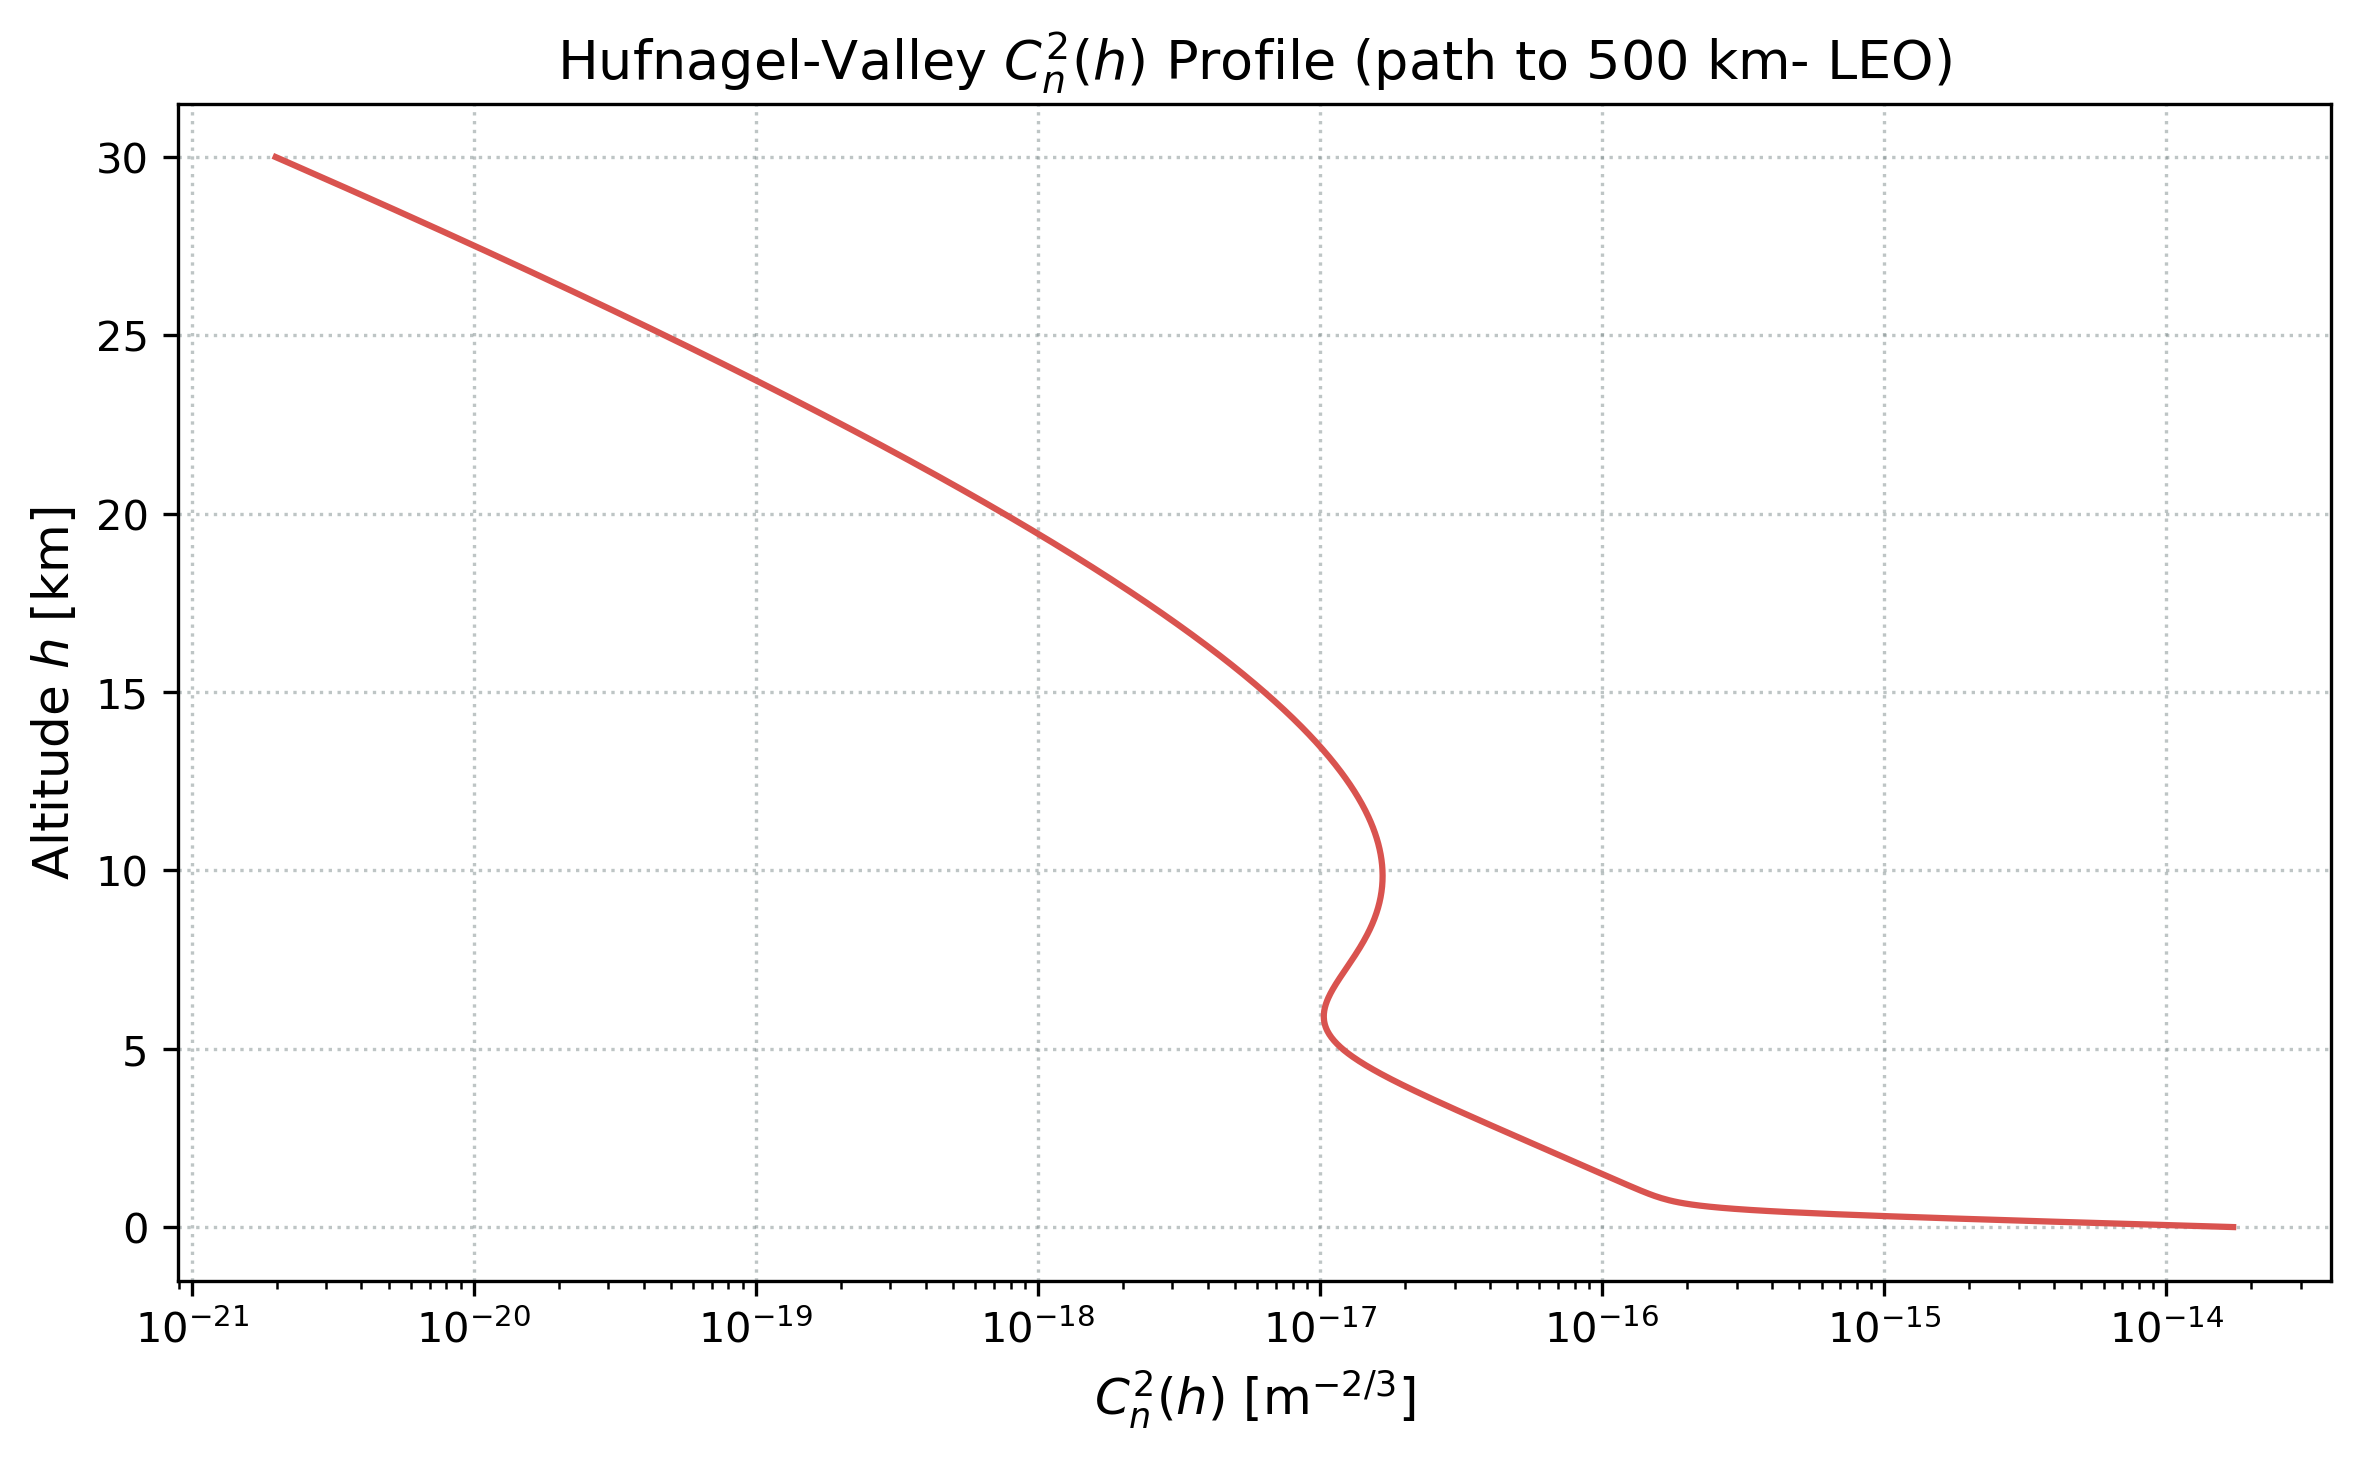

In [ ]:
def hufnagel_valley_cn2(h, A=1.7e-14, w=21):
  """Calculates the Hufnagel-Valley Cn^2(h) altitude profile up to LEO."""
  term1 = 0.00594 * (w / 27) ** 2 * (h * 1e-5) ** 10 * np.exp(-h / 1000.0)
  term2 = 2.7e-16 * np.exp(-h / 1500.0)
  term3 = A * np.exp(-h / 100.0)
  return term1 + term2 + term3


# Integration über den gesamten Weg bis zum LEO-Satelliten (500 km = 500.000 m)
h_max_leo = 500e3  # [m]


def calculate_fried_parameter_leo(
    lam, h_max=500e3, A=1.7e-14, w=21, zenith_angle_deg=0
):
  k = 2 * np.pi / lam
  sec_theta = 1.0 / np.cos(np.radians(zenith_angle_deg))

  # Integration von 0 bis 500 km
  integral, _ = quad(
      lambda h: hufnagel_valley_cn2(h, A, w), 0, h_max, limit=200
  )

  r0 = (0.423 * k**2 * sec_theta * integral) ** (-3.0 / 5.0)
  return r0


# Berechnung für 1064 nm über den vollen Weg bis 500 km
wavelength = 1064e-9  # [m]
r0_leo = calculate_fried_parameter_leo(
    wavelength, h_max=h_max_leo, zenith_angle_deg=60
)
print(f"Fried-Parameter r0 über 500 km Pfad bei 1064 nm: {r0_leo * 100:.2f} cm")

# Plotting des Profils (sinnvollerweise bis 30 km dargestellt, da danach 0)
h_plot = np.linspace(0, 30*1e3, 1000)#h_plot = np.linspace(0, 30000, 1000)
cn2_profile = hufnagel_valley_cn2(h_plot)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(cn2_profile, h_plot / 1e3, color="#D9534F")
ax.set_xscale("log")
ax.set_xlabel(r"$C_n^2(h)$ [$\text{m}^{-2/3}$]")
ax.set_ylabel("Altitude $h$ [km]")
ax.set_title("Hufnagel-Valley $C_n^2(h)$ Profile (path to 500 km- LEO)")

plt.tight_layout()

plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/calculations_for_prototype/range_divergence/atmophere/H_V(30km).pdf")
plt.show() 


#der is gut




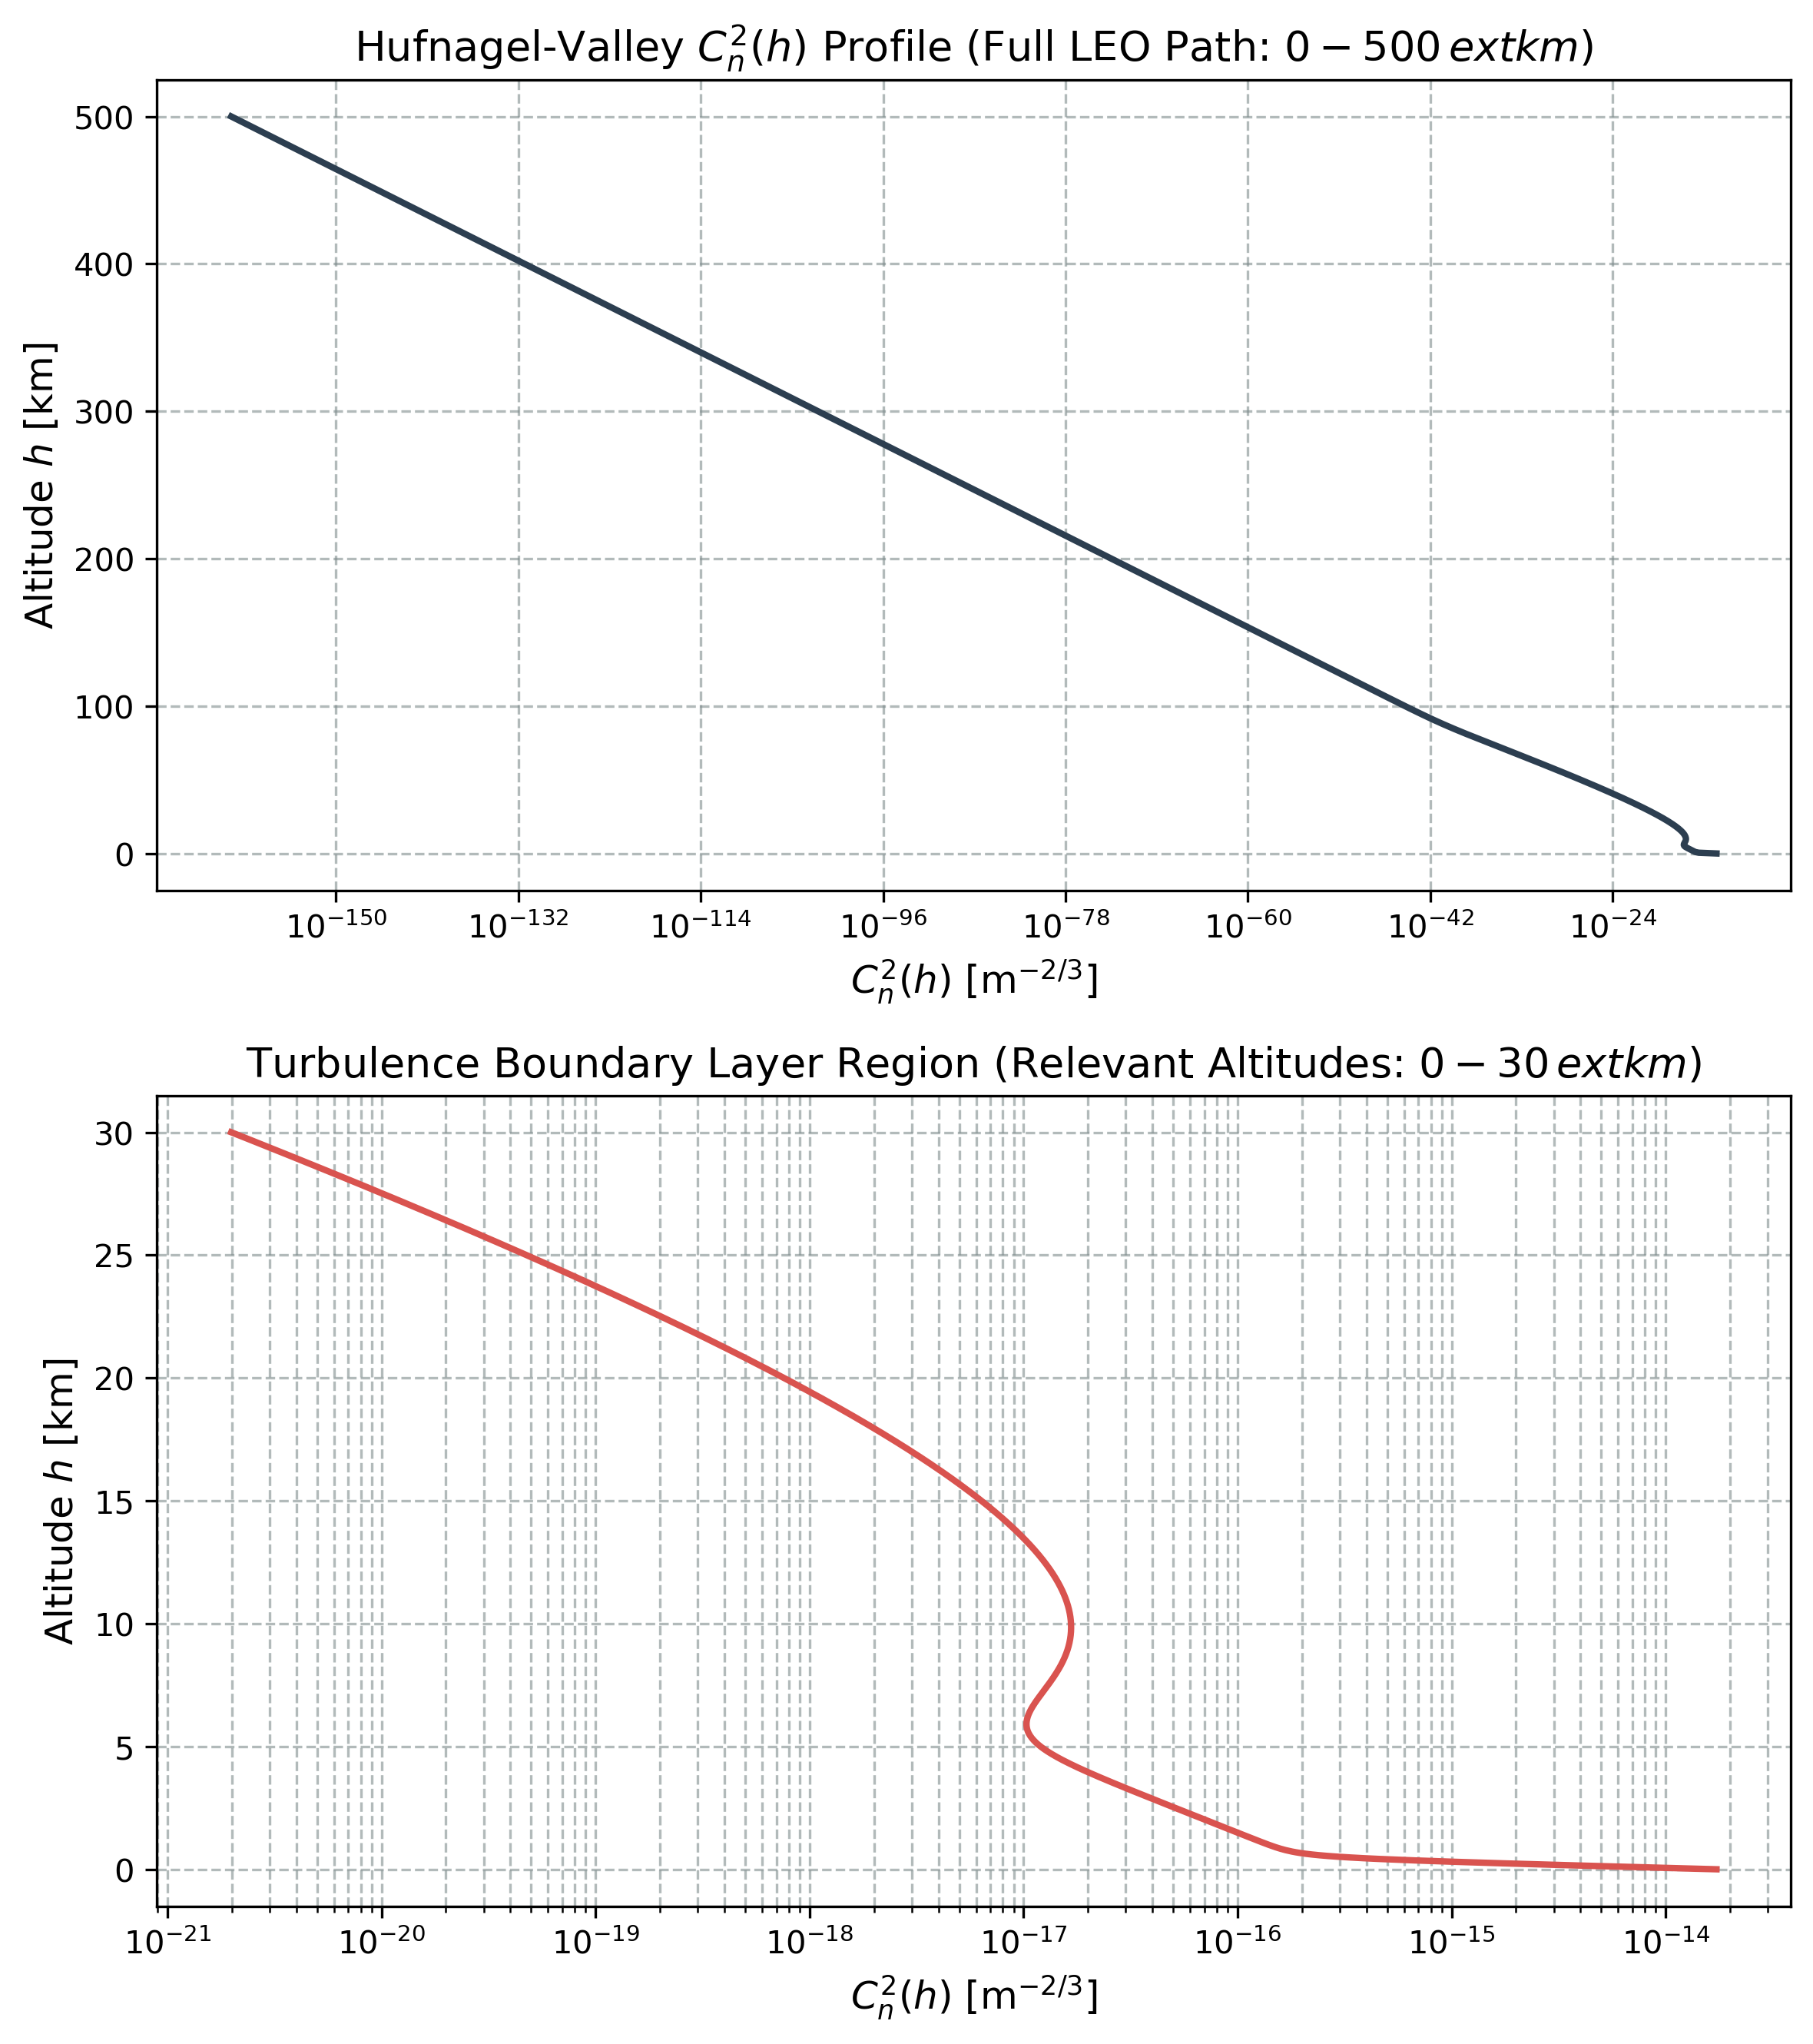

In [10]:



def hufnagel_valley_cn2(h, A=1.7e-14, w=21):
  """Calculates the Hufnagel-Valley Cn^2(h) altitude profile up to LEO."""
  term1 = 0.00594 * (w / 27) ** 2 * (h * 1e-5) ** 10 * np.exp(-h / 1000.0)
  term2 = 2.7e-16 * np.exp(-h / 1500.0)
  term3 = A * np.exp(-h / 100.0)
  return term1 + term2 + term3


# 2 Subplots untereinander (1 Spalte, 2 Zeilen)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))

# ------------------------------------------
# Plot 1: Gesamter Pfad bis LEO (0 - 500 km)
# ------------------------------------------
h_leo = np.linspace(0, 500e3, 1000)
cn2_leo = hufnagel_valley_cn2(h_leo)

ax1.plot(cn2_leo, h_leo / 1e3, color="#2C3E50", lw=2)
ax1.set_xscale("log")
ax1.set_xlabel(r"$C_n^2(h)$ [$\text{m}^{-2/3}$]")
ax1.set_ylabel("Altitude $h$ [km]")
ax1.set_title(
    "Hufnagel-Valley $C_n^2(h)$ Profile (Full LEO Path: $0-500\,\text{km}$)"
)
ax1.grid(True, which="both", linestyle="--", alpha=0.6)

# ------------------------------------------
# Plot 2: Relevanter Bereich (0 - 30 km)
# ------------------------------------------
h_turb = np.linspace(0, 30000, 1000)
cn2_turb = hufnagel_valley_cn2(h_turb)

ax2.plot(cn2_turb, h_turb / 1e3, color="#D9534F", lw=2)
ax2.set_xscale("log")
ax2.set_xlabel(r"$C_n^2(h)$ [$\text{m}^{-2/3}$]")
ax2.set_ylabel("Altitude $h$ [km]")
ax2.set_title(
    "Turbulence Boundary Layer Region (Relevant Altitudes: $0-30\,\text{km}$)"
)
ax2.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
# plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/atmosphere/hufnagel_valley_profiles.pdf")
plt.show()